In [38]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import joblib

SRC_DIR = Path("__file__").resolve().parent.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml.dl.features import extract_features as _dl_extract, FEATURE_NAMES as _TS_FEAT_NAMES

print(f"SRC_DIR: {SRC_DIR}")

SRC_DIR: /Users/alvarom/Documents/Erasmus/TFG/Bootstrap/src


## 2. Constants

In [39]:
DATA_PATH   = SRC_DIR / "data" / "FluViewPhase2Data" / "ILINet.csv"
ML_DATA_DIR = SRC_DIR / "ml" / "ml_data"
RESULTS_DIR = SRC_DIR / "results" / "flunet"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Observation windows to evaluate (weeks of data visible to the model)
OBS_WINDOWS = [10, 15, 20, 25, 30]

# Seasons to skip: 2020-21 is anomalous (COVID suppressed flu, peak ILI only 1.5%)
SKIP_SEASONS = {"2020-21"}

# Highlight a few representative seasons in trajectory plots
HIGHLIGHT = {
    "2003-04": "#E53935",   # early severe season
    "2009-10": "#FF6F00",   # H1N1 pandemic
    "2012-13": "#1E88E5",   # moderate season
    "2017-18": "#6A1B9A",   # severe season
    "2022-23": "#2E7D32",   # most recent
}

MODEL_NAMES = ["SIR", "SIS", "BP", "WTM", "H1", "H2", "H3", "H4", "H5", "H6"]

## 3. Load ILINet and split into seasons

In [40]:
# First row is a comment line — skip it
df_raw = pd.read_csv(DATA_PATH, skiprows=1)
df_nat = df_raw[df_raw["REGION TYPE"] == "National"].copy()
df_nat["ILI"] = pd.to_numeric(df_nat["%UNWEIGHTED ILI"].replace("X", np.nan))

ILI_GLOBAL_MAX = float(df_nat["ILI"].max())
print(f"National rows     : {len(df_nat)}")
print(f"Years covered     : {df_nat['YEAR'].min()} – {df_nat['YEAR'].max()}")
print(f"ILI global max    : {ILI_GLOBAL_MAX:.3f}%  (used as normalisation denominator)")


def extract_season(year: int) -> np.ndarray | None:
    """Return normalised I(t)/N for the flu season starting at week 40 of `year`."""
    mask = (
        ((df_nat["YEAR"] == year)   & (df_nat["WEEK"] >= 40)) |
        ((df_nat["YEAR"] == year+1) & (df_nat["WEEK"] <= 20))
    )
    ili = df_nat[mask].sort_values(["YEAR", "WEEK"])["ILI"].values
    if len(ili) < 25 or np.all(np.isnan(ili)):
        return None
    ili = np.nan_to_num(ili, nan=0.0)
    return (ili / ILI_GLOBAL_MAX).astype(np.float32)


seasons: dict[str, np.ndarray] = {}
for year in range(1997, 2023):
    label = f"{year}-{str(year+1)[-2:]}"
    if label in SKIP_SEASONS:
        continue
    s = extract_season(year)
    if s is not None:
        seasons[label] = s

print(f"\nSeasons loaded    : {len(seasons)}")
print(f"Season length     : {np.unique([len(v) for v in seasons.values()])} weeks")
print(f"\nPeak I_norm per season:")
for label, s in seasons.items():
    print(f"  {label}: peak={s.max():.3f}  (ILI={s.max()*ILI_GLOBAL_MAX:.2f}%)")

National rows     : 1492
Years covered     : 1997 – 2026
ILI global max    : 8.483%  (used as normalisation denominator)

Seasons loaded    : 25
Season length     : [33 34] weeks

Peak I_norm per season:
  1997-98: peak=0.579  (ILI=4.91%)
  1998-99: peak=0.599  (ILI=5.08%)
  1999-00: peak=0.666  (ILI=5.65%)
  2000-01: peak=0.494  (ILI=4.19%)
  2001-02: peak=0.373  (ILI=3.16%)
  2002-03: peak=0.373  (ILI=3.17%)
  2003-04: peak=0.833  (ILI=7.06%)
  2004-05: peak=0.560  (ILI=4.75%)
  2005-06: peak=0.360  (ILI=3.05%)
  2006-07: peak=0.385  (ILI=3.27%)
  2007-08: peak=0.639  (ILI=5.42%)
  2008-09: peak=0.450  (ILI=3.82%)
  2009-10: peak=0.898  (ILI=7.62%)
  2010-11: peak=0.523  (ILI=4.44%)
  2011-12: peak=0.270  (ILI=2.29%)
  2012-13: peak=0.710  (ILI=6.03%)
  2013-14: peak=0.517  (ILI=4.39%)
  2014-15: peak=0.721  (ILI=6.11%)
  2015-16: peak=0.423  (ILI=3.59%)
  2016-17: peak=0.561  (ILI=4.76%)
  2017-18: peak=0.919  (ILI=7.80%)
  2018-19: peak=0.640  (ILI=5.43%)
  2019-20: peak=0.867  (IL

## 4. Visualise epidemic curves

/var/folders/4r/tt5q_rzd3v14m3t1s7mk8dhr0000gn/T/ipykernel_30005/4126123736.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(seasons))


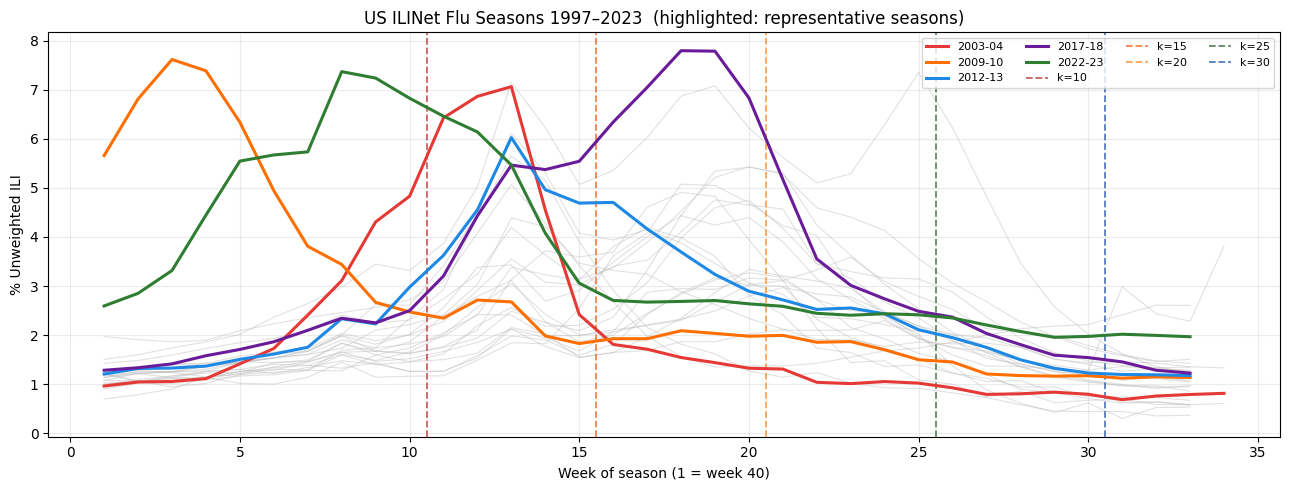

In [41]:
fig, ax = plt.subplots(figsize=(13, 5))

cmap = cm.get_cmap("tab20", len(seasons))
for i, (label, s) in enumerate(seasons.items()):
    color = HIGHLIGHT.get(label, "#BDBDBD")
    lw    = 2.2 if label in HIGHLIGHT else 0.8
    alpha = 1.0 if label in HIGHLIGHT else 0.45
    zorder = 3 if label in HIGHLIGHT else 1
    ax.plot(np.arange(1, len(s)+1), s * ILI_GLOBAL_MAX,
            color=color, lw=lw, alpha=alpha, zorder=zorder,
            label=label if label in HIGHLIGHT else None)

# observation window markers
window_colors = ["#B71C1C", "#E65100", "#F57F17", "#1B5E20", "#0D47A1", "#4A148C"]
for color, k in zip(window_colors, OBS_WINDOWS):
    ax.axvline(k + 0.5, color=color, linestyle="--", lw=1.3, alpha=0.7, label=f"k={k}")

ax.set_xlabel("Week of season (1 = week 40)")
ax.set_ylabel("% Unweighted ILI")
ax.set_title("US ILINet Flu Seasons 1997–2023  (highlighted: representative seasons)")
ax.legend(fontsize=8, ncol=4, loc="upper right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Load models and prediction helpers

In [42]:
dl_reg     = joblib.load(ML_DATA_DIR / "dl_regressor.pkl")
dl_cls     = joblib.load(ML_DATA_DIR / "dl_classifier.pkl")
ml_reg     = joblib.load(ML_DATA_DIR / "rf_regressor.pkl")
ml_cls     = joblib.load(ML_DATA_DIR / "rf_classifier.pkl")
label_enc  = joblib.load(ML_DATA_DIR / "label_encoder.pkl")
feat_names = joblib.load(ML_DATA_DIR / "feature_names.pkl")

dl_windows = getattr(dl_reg, "t_obs_available", ["?"])
print(f"DL available t_obs: {dl_windows}")
print()
print("t_obs selected per observation window k:")
for k in OBS_WINDOWS:
    candidates = [t for t in dl_windows if t <= k]
    used = max(candidates) if candidates else dl_windows[0]
    print(f"  k={k:2d} → t_obs={used}")

DL available t_obs: [10, 20, 30, 50, 75]

t_obs selected per observation window k:
  k=10 → t_obs=10
  k=15 → t_obs=10
  k=20 → t_obs=20
  k=25 → t_obs=20
  k=30 → t_obs=30


In [43]:
SIM_STEPS = 300  # simulation length the DL models were trained on

def predict_dl(I_norm: np.ndarray, k: int, rescale: bool = False):
    """DL prediction on first k weeks. Returns (rho, class_name, proba array).

    rescale=True: maps k weeks onto the simulation time axis (SIM_STEPS steps)
    and interpolates the observed series to the equivalent t_obs length.
    This corrects for the scale mismatch between 33-week ILINet seasons and
    300-step training simulations — so t_obs=75 is used from k=10 onward
    instead of t_obs=10 with zero-padding.
    """
    T_season = len(I_norm)
    obs = I_norm[:k]

    if rescale:
        s          = k * SIM_STEPS / T_season          # equivalent sim step
        dl_windows = getattr(dl_reg, "t_obs_available", [10, 20, 30, 50, 75])
        candidates = [t for t in dl_windows if t <= s]
        t_target   = max(candidates) if candidates else dl_windows[0]
        x_old = np.linspace(0, 1, k)
        x_new = np.linspace(0, 1, t_target)
        obs   = np.interp(x_new, x_old, obs).astype(np.float32)

    series = obs.reshape(1, -1)
    rho    = float(dl_reg.predict(series)[0])
    cls    = int(dl_cls.predict(series)[0])
    proba  = dl_cls.predict_proba(series)[0]
    return rho, label_enc[cls], proba


def predict_classical(I_norm: np.ndarray, k: int):
    """Classical ML prediction on hand-crafted features from first k weeks."""
    ts_vec  = _dl_extract(I_norm, k)
    ts_dict = dict(zip(_TS_FEAT_NAMES, ts_vec.tolist()))
    X = np.array([ts_dict.get(f, 0.0) for f in feat_names],
                 dtype=np.float64).reshape(1, -1)
    rho = float(ml_reg.predict(X)[0])
    cls = int(ml_cls.predict(X)[0])
    return rho, label_enc[cls]


# Show which t_obs each k maps to under both strategies
dl_windows = getattr(dl_reg, "t_obs_available", [10, 20, 30, 50, 75])
T_ref = 33
print(f"{'k':>4}  {'raw t_obs':>10}  {'rescaled sim_step':>18}  {'rescaled t_obs':>14}")
print("-" * 55)
for k in OBS_WINDOWS:
    raw_cands = [t for t in dl_windows if t <= k]
    raw_t     = max(raw_cands) if raw_cands else dl_windows[0]
    s         = k * SIM_STEPS / T_ref
    res_cands = [t for t in dl_windows if t <= s]
    res_t     = max(res_cands) if res_cands else dl_windows[0]
    print(f"{k:>4}  {raw_t:>10}  {s:>18.1f}  {res_t:>14}")

   k   raw t_obs   rescaled sim_step  rescaled t_obs
-------------------------------------------------------
  10          10                90.9              75
  15          10               136.4              75
  20          20               181.8              75
  25          20               227.3              75
  30          30               272.7              75


## 6. Run predictions — all seasons × all observation windows

In [44]:
records = []  # flat list of dicts

for season, I_norm in seasons.items():
    T = len(I_norm)
    for k in OBS_WINDOWS:
        k_eff = min(k, T)
        rho_dl, cls_dl, proba_dl = predict_dl(I_norm, k_eff)
        rho_ml, cls_ml           = predict_classical(I_norm, k_eff)
        records.append({
            "season":  season,
            "k":       k_eff,
            "DL_rho":  rho_dl,
            "DL_class": cls_dl,
            "ML_rho":  rho_ml,
            "ML_class": cls_ml,
            "peak_ILI_pct": float(I_norm.max() * ILI_GLOBAL_MAX),
            **{f"p_{m}": float(proba_dl[i]) for i, m in enumerate(MODEL_NAMES)},
        })

df = pd.DataFrame(records)
print(f"Predictions computed: {len(df)} rows ({len(seasons)} seasons × {len(OBS_WINDOWS)} windows)")
df.head(10)

Predictions computed: 125 rows (25 seasons × 5 windows)


,season,k,DL_rho,DL_class,ML_rho,ML_class,peak_ILI_pct,p_SIR,p_SIS,p_BP,p_WTM,p_H1,p_H2,p_H3,p_H4,p_H5,p_H6
0,1997-98,10,0.000221,BP,0.417945,WTM,4.91007,4.014226e-08,5.335983e-14,1.000000,4.856961e-24,4.814022e-08,5.041035e-10,2.161209e-08,1.786554e-21,6.518842e-11,6.990028e-15
1,1997-98,15,0.000221,BP,0.876595,WTM,4.91007,4.014226e-08,5.335983e-14,1.000000,4.856961e-24,4.814022e-08,5.041035e-10,2.161209e-08,1.786554e-21,6.518842e-11,6.990028e-15
2,1997-98,20,0.000681,BP,0.816229,WTM,4.91007,2.312190e-13,2.557780e-16,1.000000,6.068730e-24,2.648708e-10,6.727027e-12,7.637400e-13,7.794984e-18,4.106294e-12,1.233391e-10
3,1997-98,25,0.000681,BP,0.872521,WTM,4.91007,2.312190e-13,2.557780e-16,1.000000,6.068730e-24,2.648708e-10,6.727027e-12,7.637400e-13,7.794984e-18,4.106294e-12,1.233391e-10
4,1997-98,30,0.653042,BP,0.834564,H1,4.91007,2.668799e-12,8.868365e-14,0.999995,4.095346e-27,5.131174e-06,1.501692e-10,8.180845e-12,4.338965e-13,1.384269e-13,2.972070e-08
5,1998-99,10,0.000561,BP,0.439556,WTM,5.07760,5.128550e-06,1.374375e-09,0.999799,3.191094e-22,1.077803e-04,8.459118e-07,3.217624e-06,1.994665e-16,8.396620e-05,2.836928e-12
6,1998-99,15,0.000561,BP,0.724460,WTM,5.07760,5.128550e-06,1.374375e-09,0.999799,3.191094e-22,1.077803e-04,8.459118e-07,3.217624e-06,1.994665e-16,8.396620e-05,2.836928e-12
7,1998-99,20,0.000349,BP,0.789510,WTM,5.07760,4.381693e-13,5.744479e-12,1.000000,1.539463e-24,6.713587e-10,4.263649e-10,9.531822e-13,4.370765e-14,1.187335e-10,6.792628e-12
8,1998-99,25,0.000349,BP,0.880405,BP,5.07760,4.381693e-13,5.744479e-12,1.000000,1.539463e-24,6.713587e-10,4.263649e-10,9.531822e-13,4.370765e-14,1.187335e-10,6.792628e-12
9,1998-99,30,0.706324,BP,0.810491,BP,5.07760,1.072343e-12,1.581176e-12,0.999963,3.701216e-27,3.609703e-05,4.838751e-10,5.524145e-12,4.565777e-11,1.170577e-12,6.082245e-07


## 7. Prediction trajectories — how ρ evolves as more data arrives

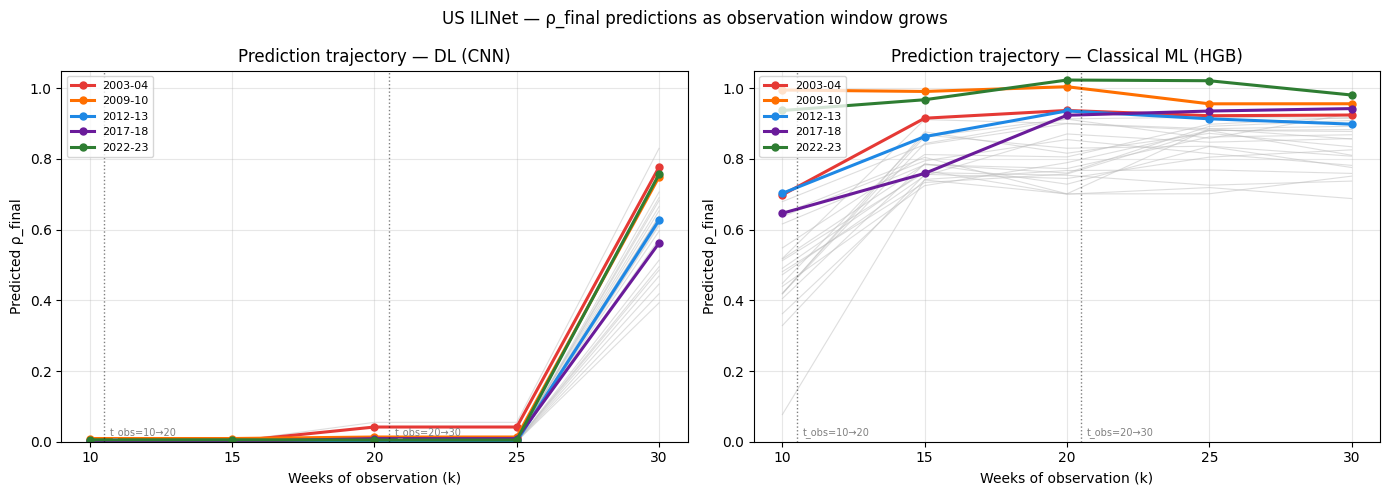

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, col, title in zip(
    axes,
    ["DL_rho", "ML_rho"],
    ["DL (CNN)", "Classical ML (HGB)"],
):
    # All seasons in grey
    for season in seasons:
        sub = df[df["season"] == season].sort_values("k")
        if season not in HIGHLIGHT:
            ax.plot(sub["k"], sub[col], color="#BDBDBD", lw=0.8, alpha=0.5)

    # Highlighted seasons on top
    for season, color in HIGHLIGHT.items():
        sub = df[df["season"] == season].sort_values("k")
        if sub.empty:
            continue
        ax.plot(sub["k"], sub[col], color=color, lw=2.2,
                marker="o", ms=5, label=season)

    ax.set_xlabel("Weeks of observation (k)")
    ax.set_ylabel("Predicted ρ_final")
    ax.set_title(f"Prediction trajectory — {title}")
    ax.set_xticks(OBS_WINDOWS)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

    # Mark t_obs transitions
    for k_switch, label in [(10, "t_obs=10→20"), (20, "t_obs=20→30")]:
        ax.axvline(k_switch + 0.5, color="black", lw=1, linestyle=":", alpha=0.5)
        ax.text(k_switch + 0.7, 0.02, label, fontsize=7, color="grey")

fig.suptitle("US ILINet — ρ_final predictions as observation window grows", fontsize=12)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Prediction stability — convergence metric

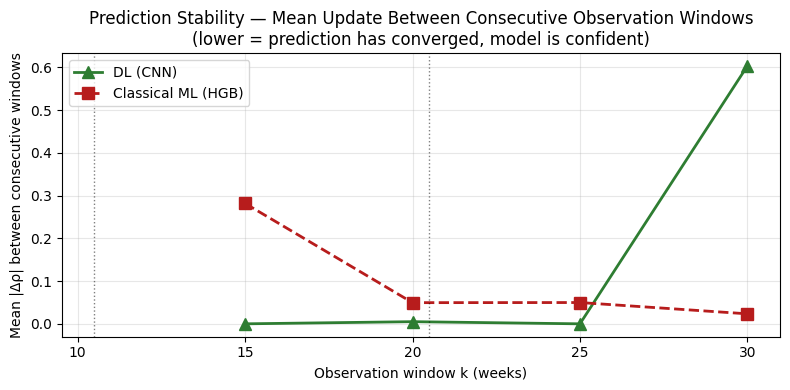

    DL_delta  ML_delta
k                     
15    0.0000    0.2815
20    0.0050    0.0495
25    0.0000    0.0498
30    0.6029    0.0234


In [46]:
# For each season, measure absolute change between consecutive windows
# Δ(k) = |pred(k) - pred(k_prev)|  — a proxy for how much the model is still "updating"

stability_rows = []
for season in seasons:
    sub = df[df["season"] == season].sort_values("k").reset_index(drop=True)
    for i in range(1, len(sub)):
        stability_rows.append({
            "season": season,
            "k":      sub.loc[i, "k"],
            "DL_delta": abs(sub.loc[i, "DL_rho"] - sub.loc[i-1, "DL_rho"]),
            "ML_delta": abs(sub.loc[i, "ML_rho"] - sub.loc[i-1, "ML_rho"]),
        })

df_stab = pd.DataFrame(stability_rows)
mean_stab = df_stab.groupby("k")[["DL_delta", "ML_delta"]].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mean_stab.index, mean_stab["DL_delta"], "^-", color="#2E7D32",
        lw=2, ms=8, label="DL (CNN)")
ax.plot(mean_stab.index, mean_stab["ML_delta"], "s--", color="#B71C1C",
        lw=2, ms=8, label="Classical ML (HGB)")

for k_switch in [10, 20]:
    ax.axvline(k_switch + 0.5, color="black", lw=1, linestyle=":", alpha=0.5)

ax.set_xlabel("Observation window k (weeks)")
ax.set_ylabel("Mean |Δρ| between consecutive windows")
ax.set_title("Prediction Stability — Mean Update Between Consecutive Observation Windows\n"
             "(lower = prediction has converged, model is confident)")
ax.set_xticks(OBS_WINDOWS)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "stability.png", dpi=150, bbox_inches="tight")
plt.show()

print(mean_stab.to_string(float_format=lambda x: f"{x:.4f}"))

## 9. Classification — which epidemic model do flu seasons resemble?

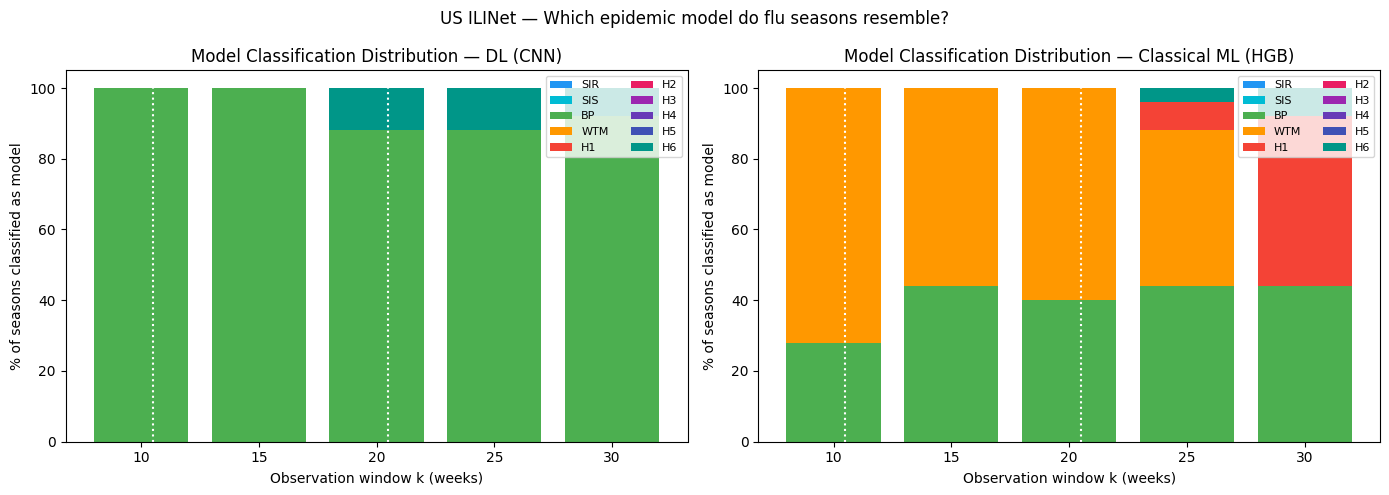

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["DL_class", "ML_class"],
    ["DL (CNN)", "Classical ML (HGB)"],
):
    counts = (
        df.groupby(["k", col])
          .size()
          .unstack(fill_value=0)
          .reindex(columns=MODEL_NAMES, fill_value=0)
    )
    counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100

    bottom = np.zeros(len(counts_pct))
    colors_map = {
        "SIR": "#2196F3", "SIS": "#00BCD4", "BP": "#4CAF50", "WTM": "#FF9800",
        "H1": "#F44336", "H2": "#E91E63", "H3": "#9C27B0", "H4": "#673AB7",
        "H5": "#3F51B5", "H6": "#009688",
    }
    for model in MODEL_NAMES:
        vals = counts_pct[model].values if model in counts_pct.columns else np.zeros(len(counts_pct))
        ax.bar(counts_pct.index, vals, bottom=bottom,
               label=model, color=colors_map[model], width=4)
        bottom += vals

    for k_switch in [10, 20]:
        ax.axvline(k_switch + 0.5, color="white", lw=1.5, linestyle=":")

    ax.set_xlabel("Observation window k (weeks)")
    ax.set_ylabel("% of seasons classified as model")
    ax.set_title(f"Model Classification Distribution — {title}")
    ax.set_xticks(OBS_WINDOWS)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8, loc="upper right", ncol=2)

fig.suptitle("US ILINet — Which epidemic model do flu seasons resemble?", fontsize=12)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "classification.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. DL class probability heatmap — average across all seasons at k = 30

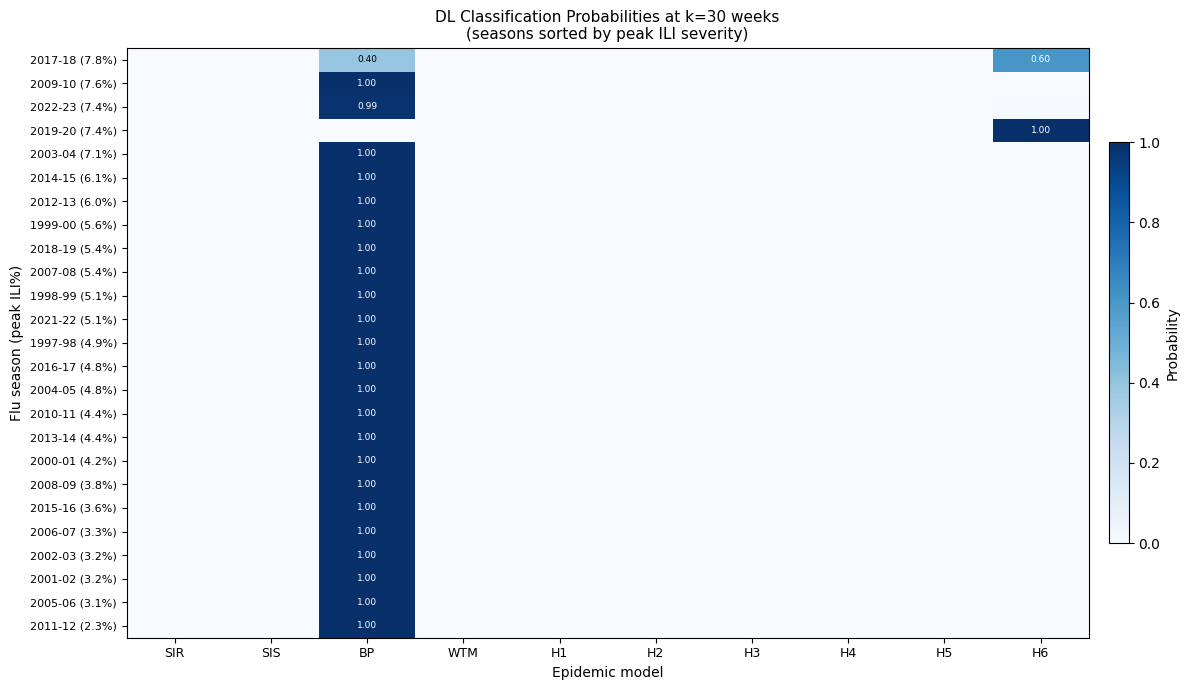

In [48]:
df_k30 = df[df["k"] == 30].copy()
prob_cols = [f"p_{m}" for m in MODEL_NAMES]

# Row per season, column per model class — sorted by peak ILI severity
df_k30_sorted = df_k30.sort_values("peak_ILI_pct", ascending=False).reset_index(drop=True)
prob_matrix = df_k30_sorted[prob_cols].values   # (n_seasons, 10)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(prob_matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(10))
ax.set_xticklabels(MODEL_NAMES, fontsize=9)
ax.set_yticks(range(len(df_k30_sorted)))
ax.set_yticklabels(
    [f"{r['season']} ({r['peak_ILI_pct']:.1f}%)" for _, r in df_k30_sorted.iterrows()],
    fontsize=8,
)
ax.set_title("DL Classification Probabilities at k=30 weeks\n(seasons sorted by peak ILI severity)",
             fontsize=11)
ax.set_xlabel("Epidemic model")
ax.set_ylabel("Flu season (peak ILI%)")

for i in range(len(df_k30_sorted)):
    for j in range(10):
        v = prob_matrix[i, j]
        if v > 0.1:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=6.5, color="white" if v > 0.55 else "black")

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="Probability")
plt.tight_layout()
fig.savefig(RESULTS_DIR / "prob_heatmap_k30.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Cross-season summary statistics

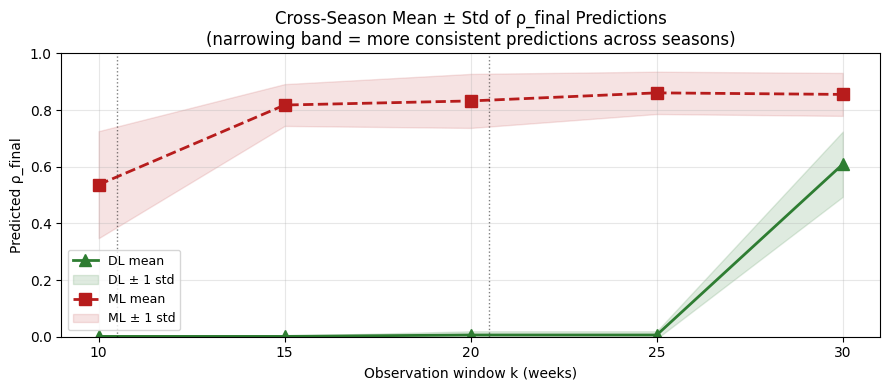

 k  DL_rho_mean  DL_rho_std  ML_rho_mean  ML_rho_std
10       0.0011      0.0019       0.5366      0.1889
15       0.0011      0.0019       0.8178      0.0738
20       0.0061      0.0132       0.8322      0.0953
25       0.0061      0.0132       0.8607      0.0747
30       0.6090      0.1151       0.8552      0.0758


In [49]:
# For each window k: mean and std of predicted rho across all seasons
summary = df.groupby("k").agg(
    DL_rho_mean=("DL_rho", "mean"),
    DL_rho_std=("DL_rho", "std"),
    ML_rho_mean=("ML_rho", "mean"),
    ML_rho_std=("ML_rho", "std"),
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(summary["k"], summary["DL_rho_mean"], "^-", color="#2E7D32", lw=2, ms=8, label="DL mean")
ax.fill_between(summary["k"],
                summary["DL_rho_mean"] - summary["DL_rho_std"],
                summary["DL_rho_mean"] + summary["DL_rho_std"],
                alpha=0.15, color="#2E7D32", label="DL ± 1 std")

ax.plot(summary["k"], summary["ML_rho_mean"], "s--", color="#B71C1C", lw=2, ms=8, label="ML mean")
ax.fill_between(summary["k"],
                summary["ML_rho_mean"] - summary["ML_rho_std"],
                summary["ML_rho_mean"] + summary["ML_rho_std"],
                alpha=0.12, color="#B71C1C", label="ML ± 1 std")

for k_switch in [10, 20]:
    ax.axvline(k_switch + 0.5, color="black", lw=1, linestyle=":", alpha=0.5)

ax.set_xlabel("Observation window k (weeks)")
ax.set_ylabel("Predicted ρ_final")
ax.set_title("Cross-Season Mean ± Std of ρ_final Predictions\n"
             "(narrowing band = more consistent predictions across seasons)")
ax.set_xticks(OBS_WINDOWS)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "cross_season_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

## 12. Comparison with the boarding school

/var/folders/4r/tt5q_rzd3v14m3t1s7mk8dhr0000gn/T/ipykernel_30005/1550109911.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


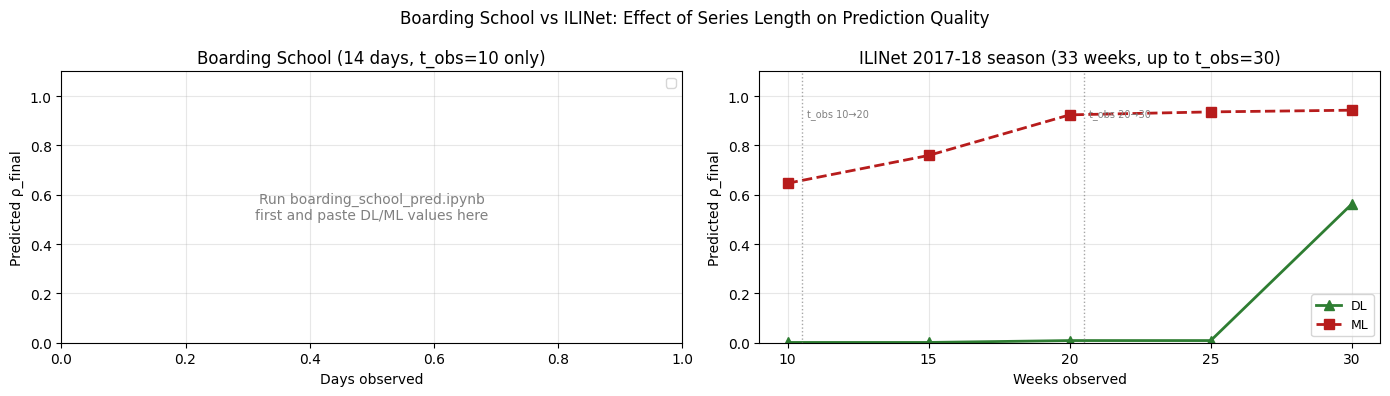

In [50]:
# Boarding school results (manually entered from the boarding_school_pred notebook)
# DL predictions at k = 3, 5, 7, 10, 14 days
bs_k   = [3, 5, 7, 10, 14]
bs_dl  = None   # fill in from boarding_school_pred notebook output
bs_ml  = None   # fill in from boarding_school_pred notebook output
bs_true = 512 / 763

# ILINet: use k = 5, 10, 15, 20, 25, 30 and the 2017-18 season as a representative example
sub_1718 = df[df["season"] == "2017-18"].sort_values("k")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: boarding school (if results are available)
ax = axes[0]
if bs_dl is not None:
    ax.plot(bs_k, bs_dl, "^-", color="#2E7D32", lw=2, ms=7, label="DL")
    ax.plot(bs_k, bs_ml, "s--", color="#B71C1C", lw=2, ms=7, label="ML")
    ax.axhline(bs_true, color="black", lw=1.5, linestyle=":", label=f"True ρ={bs_true:.3f}")
else:
    ax.text(0.5, 0.5, "Run boarding_school_pred.ipynb\nfirst and paste DL/ML values here",
            ha="center", va="center", transform=ax.transAxes, fontsize=10, color="grey")
ax.set_title("Boarding School (14 days, t_obs=10 only)")
ax.set_xlabel("Days observed")
ax.set_ylabel("Predicted ρ_final")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: ILINet 2017-18 season
ax = axes[1]
ax.plot(sub_1718["k"], sub_1718["DL_rho"], "^-", color="#2E7D32", lw=2, ms=7, label="DL")
ax.plot(sub_1718["k"], sub_1718["ML_rho"], "s--", color="#B71C1C", lw=2, ms=7, label="ML")
for k_switch, lbl in [(10, "t_obs 10→20"), (20, "t_obs 20→30")]:
    ax.axvline(k_switch + 0.5, color="grey", lw=1, linestyle=":", alpha=0.7)
    ax.text(k_switch + 0.7, 0.95, lbl, fontsize=7, color="grey", va="top")
ax.set_title("ILINet 2017-18 season (33 weeks, up to t_obs=30)")
ax.set_xlabel("Weeks observed")
ax.set_ylabel("Predicted ρ_final")
ax.set_xticks(OBS_WINDOWS)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle("Boarding School vs ILINet: Effect of Series Length on Prediction Quality",
             fontsize=12)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "comparison_boarding_vs_flunet.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Save full results table

## 14. DL vs ML — predicted ρ_final vs ground truth proxy

In [51]:
# ── Ground-truth proxy ────────────────────────────────────────────────────────
# ILINet reports weekly *prevalence* (% of visits with ILI symptoms), not
# cumulative incidence, so there is no exact rho_final.  The best single-number
# proxy for epidemic severity on the same 0-1 scale is the *peak* normalised ILI:
#   rho_true_proxy[season] = max(ILI%) / ILI_GLOBAL_MAX
# It correlates tightly with true final size in SIR-like models and is computed
# from the same normalisation used as model input.

rho_true_proxy = {s: float(arr.max()) for s, arr in seasons.items()}

# ── Table at k = 30 ───────────────────────────────────────────────────────────
df_k30 = df[df["k"] == 30][["season", "DL_rho", "ML_rho"]].copy()
df_k30["rho_true_proxy"] = df_k30["season"].map(rho_true_proxy)
df_k30["DL_err"] = (df_k30["DL_rho"] - df_k30["rho_true_proxy"]).abs()
df_k30["ML_err"] = (df_k30["ML_rho"] - df_k30["rho_true_proxy"]).abs()
df_k30 = df_k30.sort_values("rho_true_proxy", ascending=False).reset_index(drop=True)

print("Predicted ρ_final at k=30 vs ground-truth proxy (peak normalised ILI)")
print("=" * 72)
print(f"{'Season':<10} {'True proxy':>11} {'DL pred':>9} {'ML pred':>9} "
      f"{'|DL-true|':>10} {'|ML-true|':>10}")
print("-" * 72)
for _, row in df_k30.iterrows():
    print(f"{row['season']:<10} {row['rho_true_proxy']:>11.4f} "
          f"{row['DL_rho']:>9.4f} {row['ML_rho']:>9.4f} "
          f"{row['DL_err']:>10.4f} {row['ML_err']:>10.4f}")
print("-" * 72)
print(f"{'MAE':>33} {df_k30['DL_err'].mean():>9.4f} {df_k30['ML_err'].mean():>10.4f}")

# ── MAE across all observation windows ────────────────────────────────────────
mae_rows = []
for k, grp in df.groupby("k"):
    true_vals = grp["season"].map(rho_true_proxy).values
    mae_rows.append({
        "k":      k,
        "DL_MAE": float(np.abs(grp["DL_rho"].values - true_vals).mean()),
        "ML_MAE": float(np.abs(grp["ML_rho"].values - true_vals).mean()),
    })
df_mae = pd.DataFrame(mae_rows)
print(f"\nMAE vs observation window k:")
print(df_mae.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Predicted ρ_final at k=30 vs ground-truth proxy (peak normalised ILI)
Season      True proxy   DL pred   ML pred  |DL-true|  |ML-true|
------------------------------------------------------------------------
2017-18         0.9192    0.5620    0.9425     0.3571     0.0233
2009-10         0.8981    0.7493    0.9562     0.1488     0.0581
2022-23         0.8689    0.7567    0.9809     0.1122     0.1120
2019-20         0.8667    0.8300    0.8926     0.0368     0.0259
2003-04         0.8328    0.7768    0.9243     0.0559     0.0915
2014-15         0.7208    0.5736    0.9146     0.1472     0.1938
2012-13         0.7103    0.6266    0.8985     0.0837     0.1882
1999-00         0.6656    0.6382    0.8777     0.0275     0.2121
2018-19         0.6403    0.6651    0.9179     0.0248     0.2777
2007-08         0.6392    0.6906    0.8685     0.0515     0.2293
1998-99         0.5985    0.7063    0.8105     0.1078     0.2120
2021-22         0.5975    0.6366    0.8079     0.0391     0.2104
1997-98     

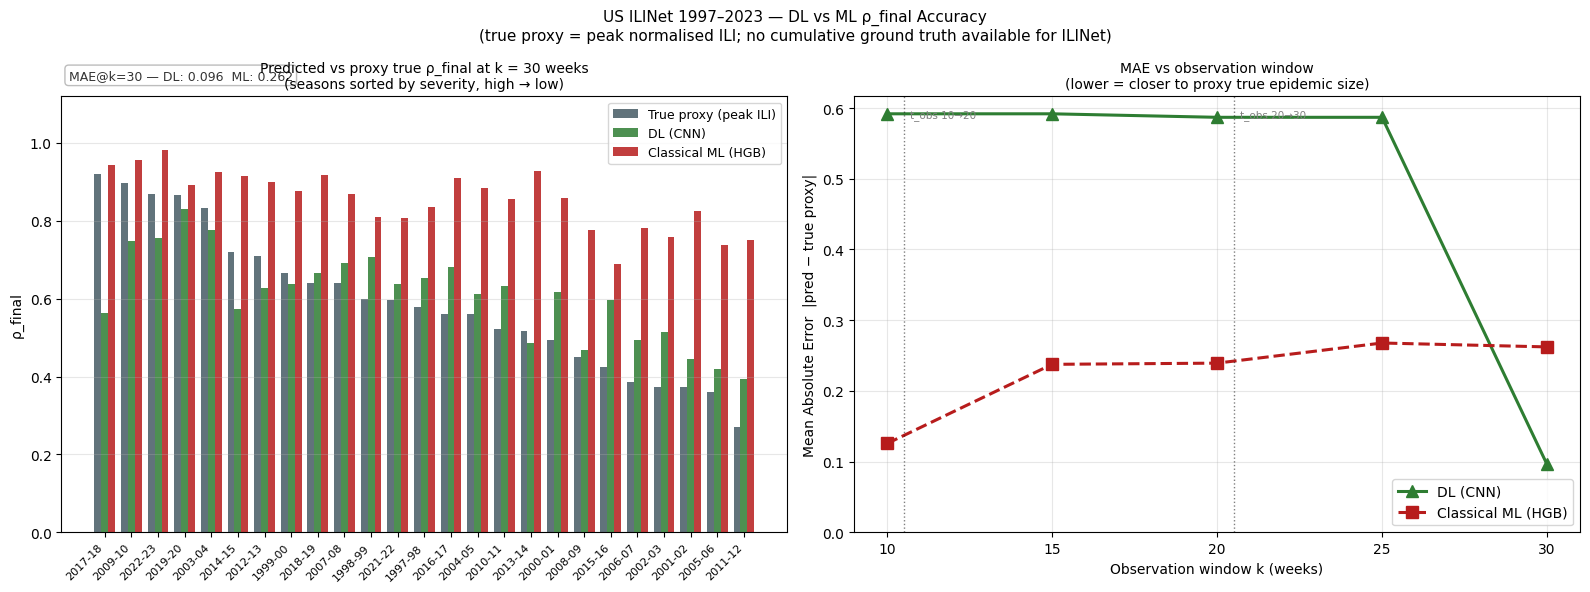

In [52]:
fig, (ax_bar, ax_mae) = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: grouped bar chart — true proxy vs DL vs ML at k=30 ─────────────────
seasons_sorted = df_k30["season"].tolist()
x = np.arange(len(seasons_sorted))
w = 0.26

bars_true = ax_bar.bar(x - w,  df_k30["rho_true_proxy"], w, label="True proxy (peak ILI)", color="#455A64", alpha=0.85)
bars_dl   = ax_bar.bar(x,      df_k30["DL_rho"],          w, label="DL (CNN)",              color="#2E7D32", alpha=0.85)
bars_ml   = ax_bar.bar(x + w,  df_k30["ML_rho"],          w, label="Classical ML (HGB)",    color="#B71C1C", alpha=0.85)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(seasons_sorted, rotation=45, ha="right", fontsize=8)
ax_bar.set_ylabel("ρ_final")
ax_bar.set_ylim(0, 1.12)
ax_bar.set_title("Predicted vs proxy true ρ_final at k = 30 weeks\n(seasons sorted by severity, high → low)",
                 fontsize=10)
ax_bar.legend(fontsize=9)
ax_bar.grid(axis="y", alpha=0.3)

# Annotate MAE summary
ax_bar.text(0.01, 1.04,
            f"MAE@k=30 — DL: {df_k30['DL_err'].mean():.3f}  ML: {df_k30['ML_err'].mean():.3f}",
            transform=ax_bar.transAxes, fontsize=9, color="#333333",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD"))

# ── Right: MAE vs observation window ─────────────────────────────────────────
ax_mae.plot(df_mae["k"], df_mae["DL_MAE"], "^-", color="#2E7D32", lw=2.2, ms=9, label="DL (CNN)")
ax_mae.plot(df_mae["k"], df_mae["ML_MAE"], "s--", color="#B71C1C", lw=2.2, ms=9, label="Classical ML (HGB)")

for k_switch, label in [(10, "t_obs 10→20"), (20, "t_obs 20→30")]:
    ax_mae.axvline(k_switch + 0.5, color="black", lw=1, linestyle=":", alpha=0.5)
    ax_mae.text(k_switch + 0.7, ax_mae.get_ylim()[1] * 0.97 if ax_mae.get_ylim()[1] > 0 else 0.97,
                label, fontsize=7.5, color="grey", va="top")

ax_mae.set_xlabel("Observation window k (weeks)")
ax_mae.set_ylabel("Mean Absolute Error  |pred − true proxy|")
ax_mae.set_title("MAE vs observation window\n(lower = closer to proxy true epidemic size)", fontsize=10)
ax_mae.set_xticks(OBS_WINDOWS)
ax_mae.set_ylim(bottom=0)
ax_mae.legend(fontsize=10)
ax_mae.grid(alpha=0.3)

fig.suptitle("US ILINet 1997–2023 — DL vs ML ρ_final Accuracy\n"
             "(true proxy = peak normalised ILI; no cumulative ground truth available for ILINet)",
             fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "rho_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Rescaled DL — correcting for the simulation / ILINet scale mismatch

In [53]:
# Run all predictions again with rescale=True
records_r = []
for season, I_norm in seasons.items():
    T = len(I_norm)
    for k in OBS_WINDOWS:
        k_eff = min(k, T)
        rho_dl_r, cls_dl_r, _ = predict_dl(I_norm, k_eff, rescale=True)
        records_r.append({"season": season, "k": k_eff,
                          "DL_rho_rescaled": rho_dl_r, "DL_class_rescaled": cls_dl_r})

df_r = pd.DataFrame(records_r)

# Merge with the original df (which already has ML_rho and DL_rho raw)
df_cmp = df[["season", "k", "DL_rho", "ML_rho"]].merge(df_r, on=["season", "k"])

# Attach true proxy
df_cmp["rho_true_proxy"] = df_cmp["season"].map(rho_true_proxy)

# MAE per window for all three approaches
mae_cmp = []
for k, grp in df_cmp.groupby("k"):
    tv = grp["rho_true_proxy"].values
    mae_cmp.append({
        "k":              k,
        "MAE_DL_raw":     float(np.abs(grp["DL_rho"].values          - tv).mean()),
        "MAE_DL_rescaled":float(np.abs(grp["DL_rho_rescaled"].values  - tv).mean()),
        "MAE_ML":         float(np.abs(grp["ML_rho"].values           - tv).mean()),
    })
df_mae_cmp = pd.DataFrame(mae_cmp)

print("MAE vs observation window — raw DL / rescaled DL / classical ML")
print("=" * 62)
print(f"{'k':>4}  {'DL raw':>10}  {'DL rescaled':>13}  {'ML':>8}")
print("-" * 44)
for _, row in df_mae_cmp.iterrows():
    print(f"{int(row['k']):>4}  {row['MAE_DL_raw']:>10.4f}  "
          f"{row['MAE_DL_rescaled']:>13.4f}  {row['MAE_ML']:>8.4f}")
print("-" * 44)
print(f"{'Mean':>4}  {df_mae_cmp['MAE_DL_raw'].mean():>10.4f}  "
      f"{df_mae_cmp['MAE_DL_rescaled'].mean():>13.4f}  "
      f"{df_mae_cmp['MAE_ML'].mean():>8.4f}")

MAE vs observation window — raw DL / rescaled DL / classical ML
   k      DL raw    DL rescaled        ML
--------------------------------------------
  10      0.5919         0.2306    0.1255
  15      0.5919         0.1786    0.2375
  20      0.5870         0.1732    0.2392
  25      0.5870         0.1942    0.2677
  30      0.0960         0.1545    0.2622
--------------------------------------------
Mean      0.4907         0.1862    0.2264


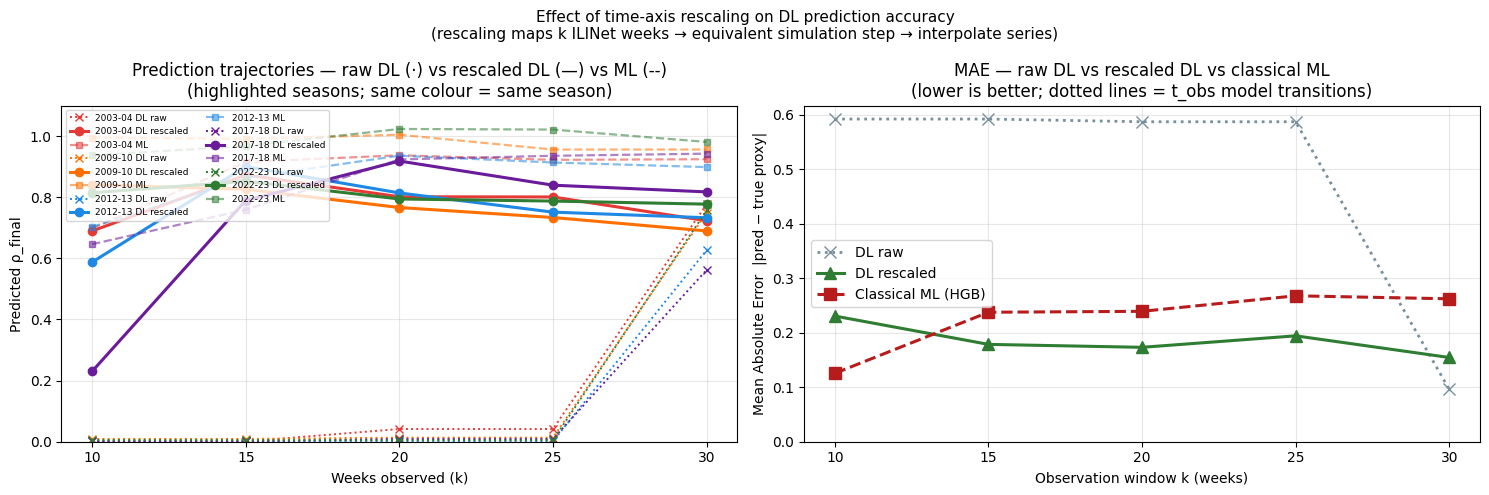

In [54]:
fig, (ax_traj, ax_mae) = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: prediction trajectories for highlighted seasons ────────────────────
for season, color in HIGHLIGHT.items():
    sub = df_cmp[df_cmp["season"] == season].sort_values("k")
    if sub.empty:
        continue
    ax_traj.plot(sub["k"], sub["DL_rho"],          color=color, lw=1.4,
                 linestyle=":",  marker="x", ms=6, label=f"{season} DL raw")
    ax_traj.plot(sub["k"], sub["DL_rho_rescaled"],  color=color, lw=2.2,
                 linestyle="-",  marker="o", ms=6, label=f"{season} DL rescaled")
    ax_traj.plot(sub["k"], sub["ML_rho"],           color=color, lw=1.6,
                 linestyle="--", marker="s", ms=5, alpha=0.55,
                 label=f"{season} ML")

ax_traj.set_xlabel("Weeks observed (k)")
ax_traj.set_ylabel("Predicted ρ_final")
ax_traj.set_title("Prediction trajectories — raw DL (·) vs rescaled DL (—) vs ML (--)\n"
                  "(highlighted seasons; same colour = same season)")
ax_traj.set_xticks(OBS_WINDOWS)
ax_traj.set_ylim(0, 1.1)
ax_traj.legend(fontsize=6.5, ncol=2, loc="upper left")
ax_traj.grid(alpha=0.3)

# ── Right: MAE comparison across windows ────────────────────────────────────
ax_mae.plot(df_mae_cmp["k"], df_mae_cmp["MAE_DL_raw"],      "x:",  color="#78909C",
            lw=2, ms=9, label="DL raw")
ax_mae.plot(df_mae_cmp["k"], df_mae_cmp["MAE_DL_rescaled"], "^-",  color="#2E7D32",
            lw=2.2, ms=9, label="DL rescaled")
ax_mae.plot(df_mae_cmp["k"], df_mae_cmp["MAE_ML"],          "s--", color="#B71C1C",
            lw=2.2, ms=9, label="Classical ML (HGB)")

ax_mae.set_xlabel("Observation window k (weeks)")
ax_mae.set_ylabel("Mean Absolute Error  |pred − true proxy|")
ax_mae.set_title("MAE — raw DL vs rescaled DL vs classical ML\n"
                 "(lower is better; dotted lines = t_obs model transitions)")
ax_mae.set_xticks(OBS_WINDOWS)
ax_mae.set_ylim(bottom=0)
ax_mae.legend(fontsize=10)
ax_mae.grid(alpha=0.3)

fig.suptitle("Effect of time-axis rescaling on DL prediction accuracy\n"
             "(rescaling maps k ILINet weeks → equivalent simulation step → interpolate series)",
             fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "rescaled_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Per-season predictions at k=20 weeks  (61 % of season observed)
Season      True proxy    DL raw   DL rescaled       ML   |DLr-true|  |ML-true|
------------------------------------------------------------------------------
2017-18          0.919     0.009         0.918    0.924        0.001      0.004
2009-10          0.898     0.013         0.766    1.004        0.132      0.106
2022-23          0.869     0.005         0.794    1.023        0.075      0.154
2019-20          0.867     0.055         0.827    0.900        0.040      0.034
2003-04          0.833     0.042         0.802    0.937        0.031      0.104
2014-15          0.721     0.002         0.787    0.913        0.066      0.193
2012-13          0.710     0.002         0.814    0.936        0.104      0.226
1999-00          0.666     0.003         0.791    0.900        0.126      0.234
2018-19          0.640     0.005         0.834    0.806        0.194      0.166
2007-08          0.639     0.001         0.901    0.773  

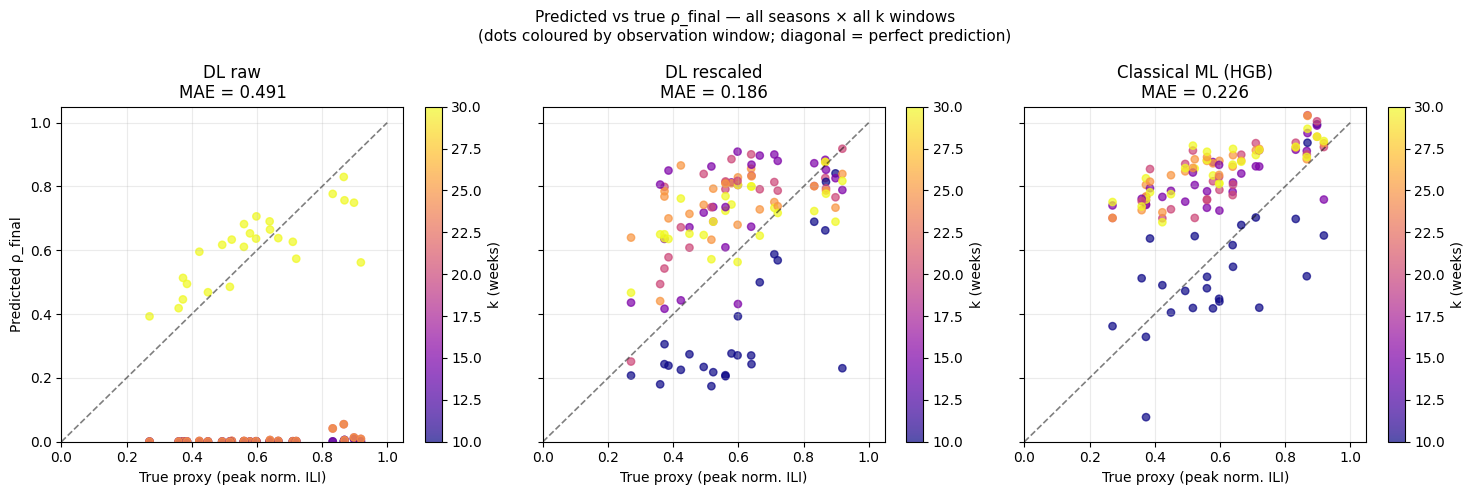

In [55]:
# ── Per-season prediction table at k = 20 (61 % of season observed) ──────────
K_SHOW = 20
sub = df_cmp[df_cmp["k"] == K_SHOW].sort_values("rho_true_proxy", ascending=False)

print(f"Per-season predictions at k={K_SHOW} weeks  (61 % of season observed)")
print("=" * 78)
print(f"{'Season':<10} {'True proxy':>11} {'DL raw':>9} {'DL rescaled':>13} {'ML':>8}  "
      f"{'|DLr-true|':>11} {'|ML-true|':>10}")
print("-" * 78)
for _, row in sub.iterrows():
    err_dl = abs(row["DL_rho_rescaled"] - row["rho_true_proxy"])
    err_ml = abs(row["ML_rho"]          - row["rho_true_proxy"])
    print(f"{row['season']:<10} {row['rho_true_proxy']:>11.3f} "
          f"{row['DL_rho']:>9.3f} {row['DL_rho_rescaled']:>13.3f} "
          f"{row['ML_rho']:>8.3f}  {err_dl:>11.3f} {err_ml:>10.3f}")
print("-" * 78)
mae_dl = sub.apply(lambda r: abs(r["DL_rho_rescaled"] - r["rho_true_proxy"]), axis=1).mean()
mae_ml = sub.apply(lambda r: abs(r["ML_rho"]          - r["rho_true_proxy"]), axis=1).mean()
print(f"{'MAE':>55} {mae_dl:>11.3f} {mae_ml:>10.3f}")

# ── Scatter: predicted vs true proxy across all k windows ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
titles = ["DL raw",         "DL rescaled",       "Classical ML (HGB)"]
cols   = ["DL_rho",         "DL_rho_rescaled",   "ML_rho"]

for ax, col, title in zip(axes, cols, titles):
    x = df_cmp["rho_true_proxy"].values
    y = df_cmp[col].values
    sc = ax.scatter(x, y, c=df_cmp["k"], cmap="plasma", s=28, alpha=0.7,
                    vmin=df_cmp["k"].min(), vmax=df_cmp["k"].max())
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="perfect prediction")
    mae = float(np.abs(y - x).mean())
    ax.set_xlabel("True proxy (peak norm. ILI)")
    if ax is axes[0]:
        ax.set_ylabel("Predicted ρ_final")
    ax.set_title(f"{title}\nMAE = {mae:.3f}")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
    plt.colorbar(sc, ax=ax, label="k (weeks)")

fig.suptitle("Predicted vs true ρ_final — all seasons × all k windows\n"
             "(dots coloured by observation window; diagonal = perfect prediction)",
             fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "scatter_pred_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
out_path = RESULTS_DIR / "flunet_predictions.csv"
df.to_csv(out_path, index=False, float_format="%.4f")
print(f"Full results saved → {out_path}")

# Summary text
lines = [
    "US ILINet — DL vs ML Prediction Summary",
    "=" * 55,
    f"Seasons: {len(seasons)}  |  Observation windows: {OBS_WINDOWS}",
    f"Normalisation: ILI / {ILI_GLOBAL_MAX:.3f}% (global max)",
    "",
    "Mean predicted rho_final per window:",
    summary[["k","DL_rho_mean","DL_rho_std","ML_rho_mean","ML_rho_std"]].to_string(index=False, float_format=lambda x: f"{x:.4f}"),
    "",
    "Mean |Δrho| between consecutive windows (stability):",
    mean_stab.to_string(float_format=lambda x: f"{x:.4f}"),
]
(RESULTS_DIR / "flunet_summary.txt").write_text("\n".join(lines) + "\n")
print(f"Summary saved     → {RESULTS_DIR / 'flunet_summary.txt'}")

Full results saved → /Users/alvarom/Documents/Erasmus/TFG/Bootstrap/src/results/flunet/flunet_predictions.csv
Summary saved     → /Users/alvarom/Documents/Erasmus/TFG/Bootstrap/src/results/flunet/flunet_summary.txt
